# Coordination Games and Q-Learning: The Escalator Game

**Methods:** Analytical Nash equilibria (pure & mixed), independent Q-learning with softmax action selection; Matplotlib

### Overview
This notebook analyzes the Nash equilibrium of an escalator game and uses Q-learning to simulate how players learn their strategies.

---

### Standing Still on Escalators

On escalators, people often stand on the left to let those who wish to walk use the right. In some regions, this is the opposite. The following game represents this situation.

- The strategy of those who stand
  - Left (Right): Stand on the left (right) side.

- The strategies of those who walk
  - Left (Right): Choose the left (right) side and proceed.

Since both players are right-handed here, choosing the right side gives a higher payoff.

$$
\begin{array}{cc|c|c}
 & & \text{walk L} & \text{walk R} \\
\hline
\text{stand} & \text{L} & 2, 2 & 4, 8 \\
\hline
 & \text{R} & 6, 7 & 3, 3 \\
\end{array}
$$

---

### 1. Nash Equilibrium

The Nash equilibria of this game are calculated for both pure and mixed strategies.

- $p$ : The probability that a person stopping will stand on the left
- $q$ : The probability that a pedestrian chooses the left side

#### (a) Pure strategy
Best response of Stand's $L$ and $R$
- Stand's best responses
    - If Walk chooses $L$: Stand gets $2$ from $L$, $6$ from $R \to \mathbf{R}$
    - If Walk chooses $R$: Stand gets $4$ from $L$, $3$ from $R \to \mathbf{L}$
  - Walk's best responses
    - If Stand chooses $L$: Walk gets $2$ from $L$, $8$ from $R \to \mathbf{R}$
    - If Stand chooses $R$: Walk gets $7$ from $L$, $3$ from $R \to \mathbf{L}$
  - Mutual best responses
    - $(\text{Stand } L, \text{ Walk } R)$
    - $(\text{Stand } R, \text{ Walk } L)$
  - Two pure Nash equilibria:
    - $(L, R) \text{ and } (R, L)$

This is a coordination (anti-coordination) game.

#### (b) Mixed strategy

Putting $p$ as probability Stand chooses $L$ and $q$ as probability Walk chooses $L$. Put the probability back in the table to make it easier to understand

$$
\begin{array}{cc|c|c}
 & & \text{walk L (q)} & \text{walk R (1-q)} \\
\hline
\text{stand (p)} & \text{L} & 2, 2 & 4, 8 \\
\hline
 \text{stand (1-p)} & \text{R} & 6, 7 & 3, 3 \\
\end{array}
$$

The expected payoff of Stand:

Choose L:
\begin{align*}
  E_s\text{(L)} = 2q +4(1-q) = 4-2q
\end{align*}

Choose R:
\begin{align*}
  E_s\text{(R)} = 6q +3(1-q) = 3+3q
\end{align*}

Indifference $4-2q = 3+3q ⇒ q^* = 0.2$

The expected payoff of Walk:

Choose L:
\begin{align*}
  E_w\text{(L)} = 2p +7(1-p) = 7-5p
\end{align*}

Choose R:
\begin{align*}
  E_w\text{(R)} = 8p +3(1-p) = 3+5p
\end{align*}

Indifference $7-5p = 3+5p ⇒ p^* = 0.4$

---

### 2. Q-Learning Simulation

The game is then simulated using Q-learning, where the payoff from the game is used as the reward. Different parameter values are tested to observe how they affect the learning results and whether the strategies converge to a Nash equilibrium.

Q-learning simulation provided in course; the Nash-equilibrium derivation (above) is my own work.

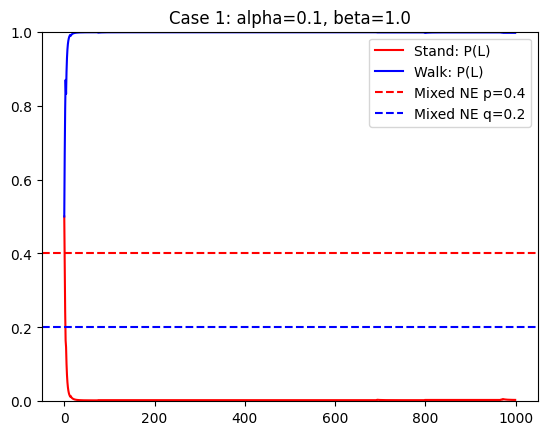

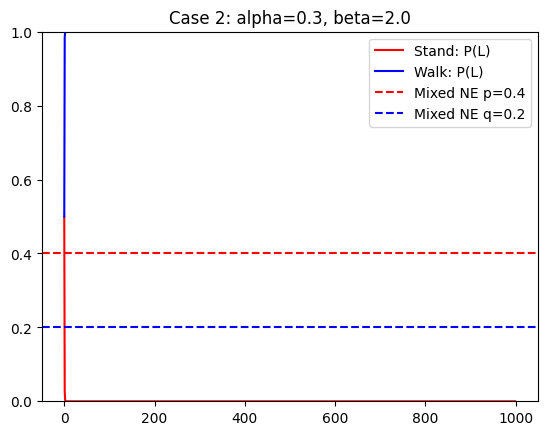

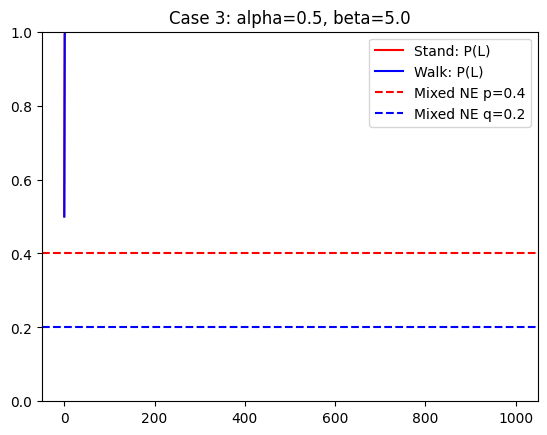

In [1]:
import matplotlib.pyplot as plt
import math
import random

laststep = 1000

# payoff matrices
Rstand=[[2,4],[6,3]]
Rwalk=[[2,8],[7,3]]

# alpha and beta
cases = [
  (0.1, 1.0),
  (0.3, 2.0),
  (0.5, 5.0)
]

for case_id, (alpha, beta) in enumerate(cases):

  # initial Q-values
  QA=QB=QC=QD=0.0

  ProbabilityA=[None for _ in range(laststep)]
  ProbabilityC=[None for _ in range(laststep)]
  time=[i for i in range(laststep)]

  for t in range(laststep):

    # Stand choose
    PActionA=math.exp(beta*QA)/(math.exp(beta*QA)+math.exp(beta*QB))
    ProbabilityA[t]=PActionA

    # Walk choose
    PActionC=math.exp(beta*QC)/(math.exp(beta*QC)+math.exp(beta*QD))
    ProbabilityC[t]=PActionC

    if PActionA > random.random():
      aS=0
    else:
      aS=1

    if PActionC > random.random():
      aW=0
    else:
      aW=1

    rS=Rstand[aS][aW]
    rW=Rwalk[aS][aW]

    if aS==0:
      QA += alpha*(rS-QA)
    else:
      QB += alpha*(rS-QB)

    if aW==0:
      QC += alpha*(rW-QC)
    else:
      QD += alpha*(rW-QD)

  # plot
  plt.figure()
  plt.plot(time, ProbabilityA, c="red", label="Stand: P(L)")
  plt.plot(time, ProbabilityC, c="blue", label="Walk: P(L)")
  plt.axhline(0.4, linestyle="--", c="red", label="Mixed NE p=0.4")
  plt.axhline(0.2, linestyle="--", c="blue", label="Mixed NE q=0.2")
  plt.ylim(0,1)
  plt.title(f"Case {case_id+1}: alpha={alpha}, beta={beta}")
  plt.legend()
  # plt.savefig(f"case{case_id+1}.png")
  plt.show()

---

### Discussion

When the payoff of the escalator game is used as the reward in independent Q-learning, simulations show convergence to one of the pure Nash equilibria. The mixed-strategy Nash equilibrium is not observed as a stable outcome.

Increasing the learning rate α and inverse temperature β accelerates convergence and strengthens equilibrium selection.